# Phase 9 — Statistical Analysis

Goes beyond simple point-estimate comparison (Phase 6) with proper
paired statistical tests, since all three models were evaluated on
the exact same 195 test images / same ground-truth boxes.

In [1]:
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

with open(PROJECT_ROOT / "results" / "statistical_tests" / "statistical_tests.json") as f:
    stats_results = json.load(f)

models = list(stats_results["bootstrap_ci"].keys())
models

['YOLOv8n', 'RT-DETR-L', 'DEIMv2-Nano (DINO sub.)']

## Bootstrap 95% Confidence Intervals

In [2]:
metrics = ["precision", "recall", "f1_score", "mAP50", "mAP50_95"]

rows = []
for model in models:
    for metric in metrics:
        d = stats_results["bootstrap_ci"][model][metric]
        rows.append({
            "Model": model, "Metric": metric,
            "Point estimate": d["point_estimate"],
            "95% CI lower": d["ci_95_lower"],
            "95% CI upper": d["ci_95_upper"],
        })

ci_df = pd.DataFrame(rows)
ci_df.pivot(index="Metric", columns="Model", values="Point estimate")

Model,DEIMv2-Nano (DINO sub.),RT-DETR-L,YOLOv8n
Metric,,,
f1_score,0.9241,0.9511,0.9154
mAP50,0.9636,0.9703,0.9201
mAP50_95,0.6552,0.6518,0.6061
precision,0.9133,0.9400,0.9266
recall,0.9352,0.9625,0.9044


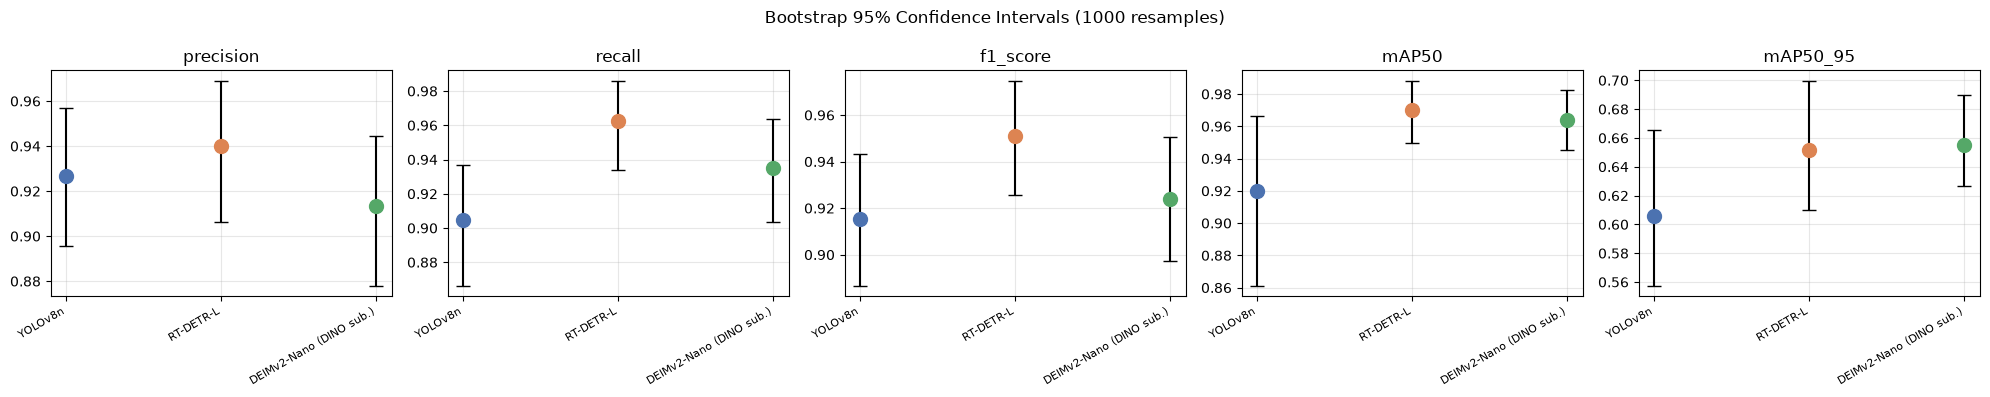

In [3]:
fig, axes = plt.subplots(1, len(metrics), figsize=(20, 4), sharey=False)
colors = ["#4C72B0", "#DD8452", "#55A868"]

for ax, metric in zip(axes, metrics):
    sub = ci_df[ci_df["Metric"] == metric]
    x = range(len(models))
    points = sub["Point estimate"].values
    lower_err = points - sub["95% CI lower"].values
    upper_err = sub["95% CI upper"].values - points

    ax.errorbar(x, points, yerr=[lower_err, upper_err], fmt="o", capsize=5,
                color="black", markersize=8)
    for i, c in zip(x, colors):
        ax.plot(i, points[i], "o", color=c, markersize=10, zorder=3)

    ax.set_xticks(list(x))
    ax.set_xticklabels(models, rotation=30, ha="right", fontsize=8)
    ax.set_title(metric)
    ax.grid(alpha=0.3)

plt.suptitle("Bootstrap 95% Confidence Intervals (1000 resamples)")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "report" / "figures" / "bootstrap_confidence_intervals.png", dpi=150)
plt.show()

**How to read this:** if two models' error bars for a given metric
don't overlap, that's strong visual evidence of a real difference
(not just noise). Overlapping bars don't necessarily mean "no
difference" -- the paired tests below are more precise, since they
account for the fact both models were tested on the SAME images.

## Paired Permutation Test (per-image F1 score)

Tests whether the mean per-image F1 difference between two models is
larger than expected by chance, using 10,000 random sign-flips to
build a null distribution. Paired by image, so it directly answers
"does one model do better than the other on the same images," not
just "are the aggregate numbers different."

In [4]:
perm_rows = []
for pair, result in stats_results["paired_permutation"].items():
    perm_rows.append({
        "Comparison": pair,
        "Mean F1 difference": result["observed_mean_diff"],
        "p-value": result["p_value"],
        "Cohen's d": result["effect_size_cohens_d"],
        "Significant (p<0.05)": "Yes" if result["p_value"] < 0.05 else "No",
    })

perm_df = pd.DataFrame(perm_rows)
perm_df

,Comparison,Mean F1 difference,p-value,Cohen's d,Significant (p<0.05)
0,YOLOv8n vs RT-DETR-L,-0.0552,0.0001,-0.2554,Yes
1,YOLOv8n vs DEIMv2-Nano (DINO sub.),-0.0231,0.2097,-0.0909,No
2,RT-DETR-L vs DEIMv2-Nano (DINO sub.),0.0321,0.0146,0.1701,Yes


## Wilcoxon Signed-Rank Test (per-image F1 score)

Non-parametric alternative to a paired t-test -- doesn't assume the
per-image score differences are normally distributed, which is safer
given F1 scores are bounded [0,1] and often skewed.

In [5]:
wilcoxon_rows = []
for pair, result in stats_results["wilcoxon"].items():
    wilcoxon_rows.append({
        "Comparison": pair,
        "Statistic": result.get("statistic"),
        "p-value": result["p_value"],
        "Significant (p<0.05)": "Yes" if result["p_value"] < 0.05 else "No",
    })

wilcoxon_df = pd.DataFrame(wilcoxon_rows)
wilcoxon_df

,Comparison,Statistic,p-value,Significant (p<0.05)
0,YOLOv8n vs RT-DETR-L,88.5,0.0005,Yes
1,YOLOv8n vs DEIMv2-Nano (DINO sub.),294.0,0.2618,No
2,RT-DETR-L vs DEIMv2-Nano (DINO sub.),133.0,0.0131,Yes


## McNemar's Test (per-ground-truth-box correct/incorrect, paired)

Directly tests whether two models disagree systematically on which
*specific* defects they catch. Each ground-truth box is a paired
"trial": did model A catch it, did model B catch it. The contingency
table shows how often they agree/disagree.

In [6]:
mcnemar_rows = []
for pair, result in stats_results["mcnemar"].items():
    t = result["contingency_table"]
    mcnemar_rows.append({
        "Comparison": pair,
        "Both correct": t["both_correct"],
        "Only A correct": t["a_only_correct"],
        "Only B correct": t["b_only_correct"],
        "Both wrong": t["both_wrong"],
        "p-value": result["p_value"],
        "Significant (p<0.05)": "Yes" if result["p_value"] < 0.05 else "No",
    })

mcnemar_df = pd.DataFrame(mcnemar_rows)
mcnemar_df

,Comparison,Both correct,Only A correct,Only B correct,Both wrong,p-value,Significant (p<0.05)
0,YOLOv8n vs RT-DETR-L,262,3,20,8,0.0005,Yes
1,YOLOv8n vs DEIMv2-Nano (DINO sub.),256,9,18,10,0.1237,No
2,RT-DETR-L vs DEIMv2-Nano (DINO sub.),271,11,3,8,0.0574,No


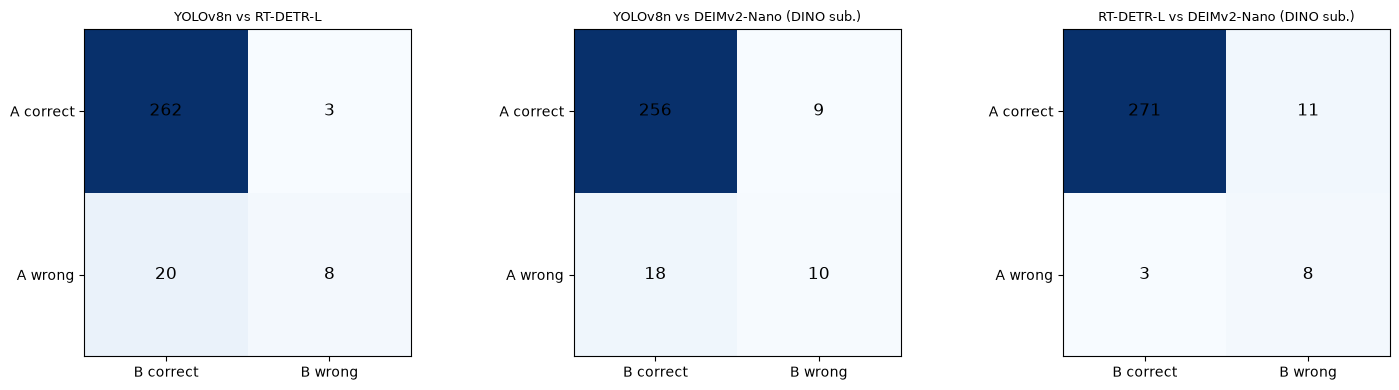

In [7]:
fig, axes = plt.subplots(1, len(mcnemar_df), figsize=(15, 4))

for ax, (_, row) in zip(axes, mcnemar_df.iterrows()):
    table = np.array([[row["Both correct"], row["Only A correct"]],
                       [row["Only B correct"], row["Both wrong"]]])
    im = ax.imshow(table, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, int(table[i, j]), ha="center", va="center", fontsize=12)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["B correct", "B wrong"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["A correct", "A wrong"])
    ax.set_title(row["Comparison"], fontsize=9)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "report" / "figures" / "mcnemar_contingency_tables.png", dpi=150)
plt.show()

fig, axes = plt.subplots(1, len(mcnemar_df), figsize=(15, 4))

for ax, (_, row) in zip(axes, mcnemar_df.iterrows()):
    table = np.array([[row["Both correct"], row["Only A correct"]],
                       [row["Only B correct"], row["Both wrong"]]])
    im = ax.imshow(table, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, int(table[i, j]), ha="center", va="center", fontsize=12)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["B correct", "B wrong"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["A correct", "A wrong"])
    ax.set_title(row["Comparison"], fontsize=9)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "report" / "figures" / "mcnemar_contingency_tables.png", dpi=150)
plt.show()